In [2]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features)-2)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weights, self.bias)

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()

In [17]:
def sparsity_loss(model):
    loss = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.mean()   # cleaner & stable

    return loss

In [18]:
def train_model(lambda_val, epochs=10):
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        total_loss = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 🔥 KEY LINE
            loss += lambda_val * sparsity_loss(model)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

    return model

In [19]:
def evaluate(model):
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [20]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [11]:
def apply_threshold_pruning(model, threshold=0.1):
    pruned_params = 0
    total_params = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            mask = (gates > threshold).float()
            module.weight.data *= mask

            pruned_params += (mask == 0).sum().item()
            total_params += mask.numel()

    print(f"Hard Pruned: {100 * pruned_params / total_params:.2f}% weights removed")

In [24]:
lambdas = [0.1, 0.5, 1.0]
results = []
models = {}

for lam in lambdas:
    model = train_model(lam, epochs=10)

    #apply_threshold_pruning(model, threshold=0.1)

    models[lam] = model   # 🔥 store model

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

Epoch 1, Loss: 1639.48
Epoch 2, Loss: 1503.26
Epoch 3, Loss: 1430.50
Epoch 4, Loss: 1363.81
Epoch 5, Loss: 1320.79
Epoch 6, Loss: 1283.85
Epoch 7, Loss: 1254.79
Epoch 8, Loss: 1229.42
Epoch 9, Loss: 1208.37
Epoch 10, Loss: 1187.96
Epoch 1, Loss: 1771.01
Epoch 2, Loss: 1617.24
Epoch 3, Loss: 1533.15
Epoch 4, Loss: 1460.97
Epoch 5, Loss: 1403.65
Epoch 6, Loss: 1365.39
Epoch 7, Loss: 1334.16
Epoch 8, Loss: 1304.52
Epoch 9, Loss: 1278.06
Epoch 10, Loss: 1258.74
Epoch 1, Loss: 1928.34
Epoch 2, Loss: 1719.18
Epoch 3, Loss: 1600.46
Epoch 4, Loss: 1514.26
Epoch 5, Loss: 1453.07
Epoch 6, Loss: 1410.05
Epoch 7, Loss: 1378.56
Epoch 8, Loss: 1347.56
Epoch 9, Loss: 1321.40
Epoch 10, Loss: 1299.26


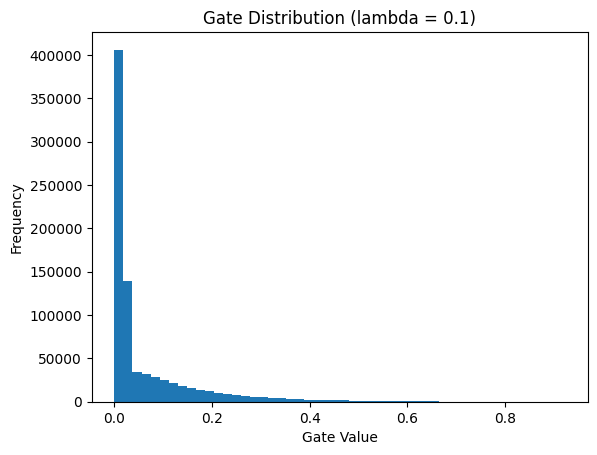

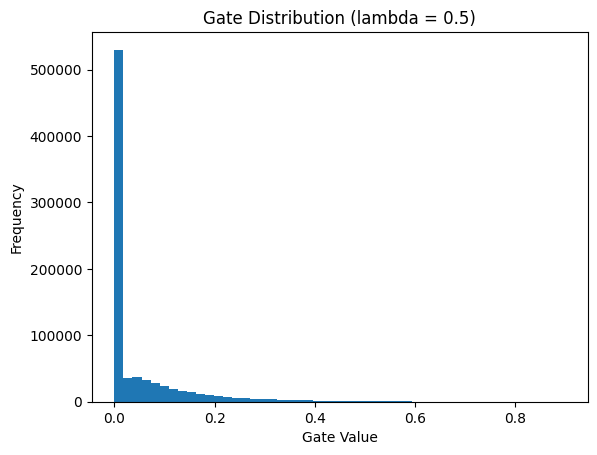

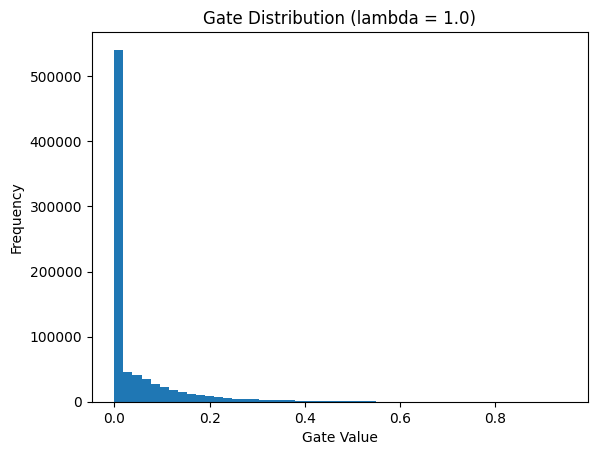

In [25]:
import matplotlib.pyplot as plt

for lam, model in models.items():
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title(f"Gate Distribution (lambda = {lam})")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

In [26]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity")

for r in results:
    print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")


Final Results:
Lambda | Accuracy | Sparsity
0.1 | 46.36% | 10.76%
0.5 | 43.74% | 58.11%
1.0 | 44.43% | 61.39%
